In [1]:
!pip install -U pandas numpy scikit-learn shap matplotlib openpyxl



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import pandas as pd

TCRI_PATH = 'tcri.csv'
FIN_PATH  = 'ratios_filled_with_gics_category.csv'
OUT_DIR   = 'outputs/nn_model'

os.makedirs(OUT_DIR, exist_ok=True)
os.environ['OUT_DIR'] = OUT_DIR

print('tcri.csv exists?', os.path.exists(TCRI_PATH))
print('ratios_filled_with_gics_category.csv exists?', os.path.exists(FIN_PATH))


tcri.csv exists? True
ratios_filled_with_gics_category.csv exists? True


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Params {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'learning_rate_init': 0.001} -> PR-AUC(valid)=0.7469


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
Using 2000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Params {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.0005} -> PR-AUC(valid)=0.7633
[INFO] Best validation PR-AUC: 0.7633
[INFO] Thresholds: t_f1=0.3121, t_at_precision=0.1523
{
  "pr_auc": 0.6673685161344695,
  "roc_auc": 0.8153885220924327,
  "f1": 0.6365795724465558,
  "precision": 0.5537190082644629,
  "recall": 0.7486033519553073,
  "brier": 0.15204290610502252,
  "logloss": 0.4703277853012037,
  "ece": 0.053897960960753485,
  "threshold": 0.31213512709362423,
  "recall_at_p>=0.50": 0.8156424581005587,
  "threshold_at_p>=0.50": 0.2392505082549974
}
Artifacts saved to outputs/nn_model


100%|██████████| 619/619 [33:01<00:00,  3.20s/it]




Generating Reliability Curve...


ValueError: Found input variables with inconsistent numbers of samples: [619, 2]

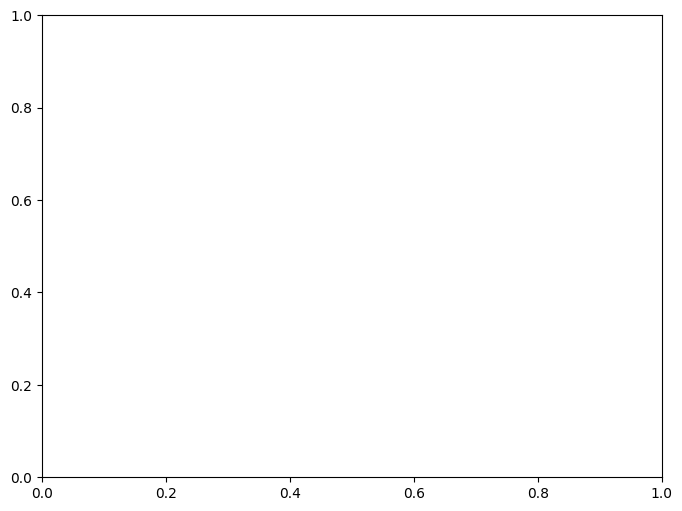

In [3]:
import json
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

from src.data_prep import load_and_prepare, create_label_next_period, time_split, detect_feature_columns
from src.metrics import best_f1_threshold, threshold_at_precision
from src.explain import run_shap_for_model
from src.modeling.logistic_pipeline import predict_with_calibration
from src.reporting import aggregate_slice_metrics, evaluate_predictions, prepare_prediction_frame, save_artifacts

# Use the merged data from the baseline model's output
CSV_PATH = 'outputs/logistic_baseline/merged.csv'
ID_COL = 'coid'
DATE_COL = 'mdate'
TCRI_COL = 'tcri'
GICS_COL = 'GICS_Category'
TAU = 7
HORIZON = 1
train_start, train_end = '2014-01-01', '2021-12-31'
valid_start, valid_end = '2022-01-01', '2022-12-31'
test_start, test_end = '2023-01-01', '2023-12-31'

df = load_and_prepare(CSV_PATH, ID_COL, DATE_COL, None, TCRI_COL)
df = create_label_next_period(df, ID_COL, TCRI_COL, TAU, HORIZON)
train, valid, test = time_split(df, DATE_COL, train_start, train_end, valid_start, valid_end, test_start, test_end)
num_cols, cat_cols = detect_feature_columns(train, ID_COL, DATE_COL, TCRI_COL, categorical_cols=[GICS_COL])

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

param_grid = [
    {'hidden_layer_sizes': (64, 32), 'alpha': 1e-4, 'learning_rate_init': 1e-3},
    {'hidden_layer_sizes': (128, 64), 'alpha': 1e-4, 'learning_rate_init': 5e-4},
]

best_model = None
best_score = -np.inf
for params in param_grid:
    clf = MLPClassifier(
        max_iter=200,
        random_state=42,
        **params,
    )
    pipe = Pipeline([('pre', pre), ('clf', clf)])
    pipe.fit(train[num_cols + cat_cols], train['y'])
    p_valid = pipe.predict_proba(valid[num_cols + cat_cols])[:, 1]
    score = average_precision_score(valid['y'], p_valid)
    print(f'Params {params} -> PR-AUC(valid)={score:.4f}')
    if score > best_score:
        best_score = score
        best_model = pipe

print(f'[INFO] Best validation PR-AUC: {best_score:.4f}')

valid_features = valid[num_cols + cat_cols]
test_features = test[num_cols + cat_cols]
p_valid_best = best_model.predict_proba(valid_features)[:, 1]
t_f1 = best_f1_threshold(valid['y'].values, p_valid_best)
t_rp = threshold_at_precision(valid['y'].values, p_valid_best, 0.5)
print(f'[INFO] Thresholds: t_f1={t_f1:.4f}, t_at_precision={t_rp:.4f}')

probs = predict_with_calibration(best_model, valid_features, valid['y'], test_features)
metrics = evaluate_predictions(test['y'].values, probs, threshold=t_f1, target_precision=0.5)
metrics['thresholds'] = {'t_f1': t_f1, 't_at_precision': t_rp, 'precision_target': 0.5}
metrics['valid_pr_auc_for_best_params'] = float(best_score)

slice_tables = {
    'quarter': aggregate_slice_metrics(test, probs, 'quarter', threshold=t_f1, target_precision=0.5),
}
if GICS_COL in test.columns:
    slice_tables[GICS_COL] = aggregate_slice_metrics(test, probs, GICS_COL, threshold=t_f1, target_precision=0.5)

feature_names = best_model.named_steps['pre'].get_feature_names_out()
# MLP 沒有 feature_importances_，這裡先放佔位
feature_weights = pd.DataFrame({
    'feature': feature_names,
    'coefficient': np.nan,
    'abs_coefficient': np.nan,
})

preds = prepare_prediction_frame(test, ID_COL, DATE_COL, probs)
save_artifacts(preds, metrics, feature_weights, slice_tables, os.environ['OUT_DIR'])

print(json.dumps(metrics['raw'], indent=2))
print('Artifacts saved to', os.environ['OUT_DIR'])

pretrained = best_model.named_steps['clf']
dense_train = best_model.named_steps['pre'].transform(train[num_cols + cat_cols])
dense_test = best_model.named_steps['pre'].transform(test[num_cols + cat_cols])
run_shap_for_model(
    fitted_model=pretrained,
    X_train=dense_train,
    X_test=dense_test,
    feature_names=feature_names,
    model_name='nn_model'
)

# Plot and save reliability curve
print("\nGenerating Reliability Curve...")
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    test['y'],
    probs,
    n_bins=10,
    strategy='uniform',
    ax=ax,
    name='Neural Network'
)
ax.set_title('Reliability Curve (Neural Network)')
plt.grid(True)
plot_path = os.path.join('outputs', 'plots', 'reliability_curve_nn_model.png')
plt.savefig(plot_path)
print(f"Reliability curve saved to {plot_path}")
plt.show()


In [ ]:
OUT_DIR = os.environ['OUT_DIR']
with open(f'{OUT_DIR}/metrics_summary.json', 'r', encoding='utf-8') as f:
    summary = json.load(f)
summary

pd.read_csv(f'{OUT_DIR}/metrics_by_quarter.csv').head()


,slice,n,pos,raw.pr_auc,raw.roc_auc,raw.f1,raw.precision,raw.recall,raw.brier,raw.logloss,...,isotonic.roc_auc,isotonic.f1,isotonic.precision,isotonic.recall,isotonic.brier,isotonic.logloss,isotonic.ece,isotonic.threshold,isotonic.recall_at_p>=0.50,isotonic.threshold_at_p>=0.50
0,quarter=2023Q4,619,179,0.686438,0.822245,0.636145,0.559322,0.73743,0.150065,0.485935,...,0.82201,0.609603,0.486667,0.815642,0.152541,0.525073,0.083504,0.260046,0.73743,0.417722


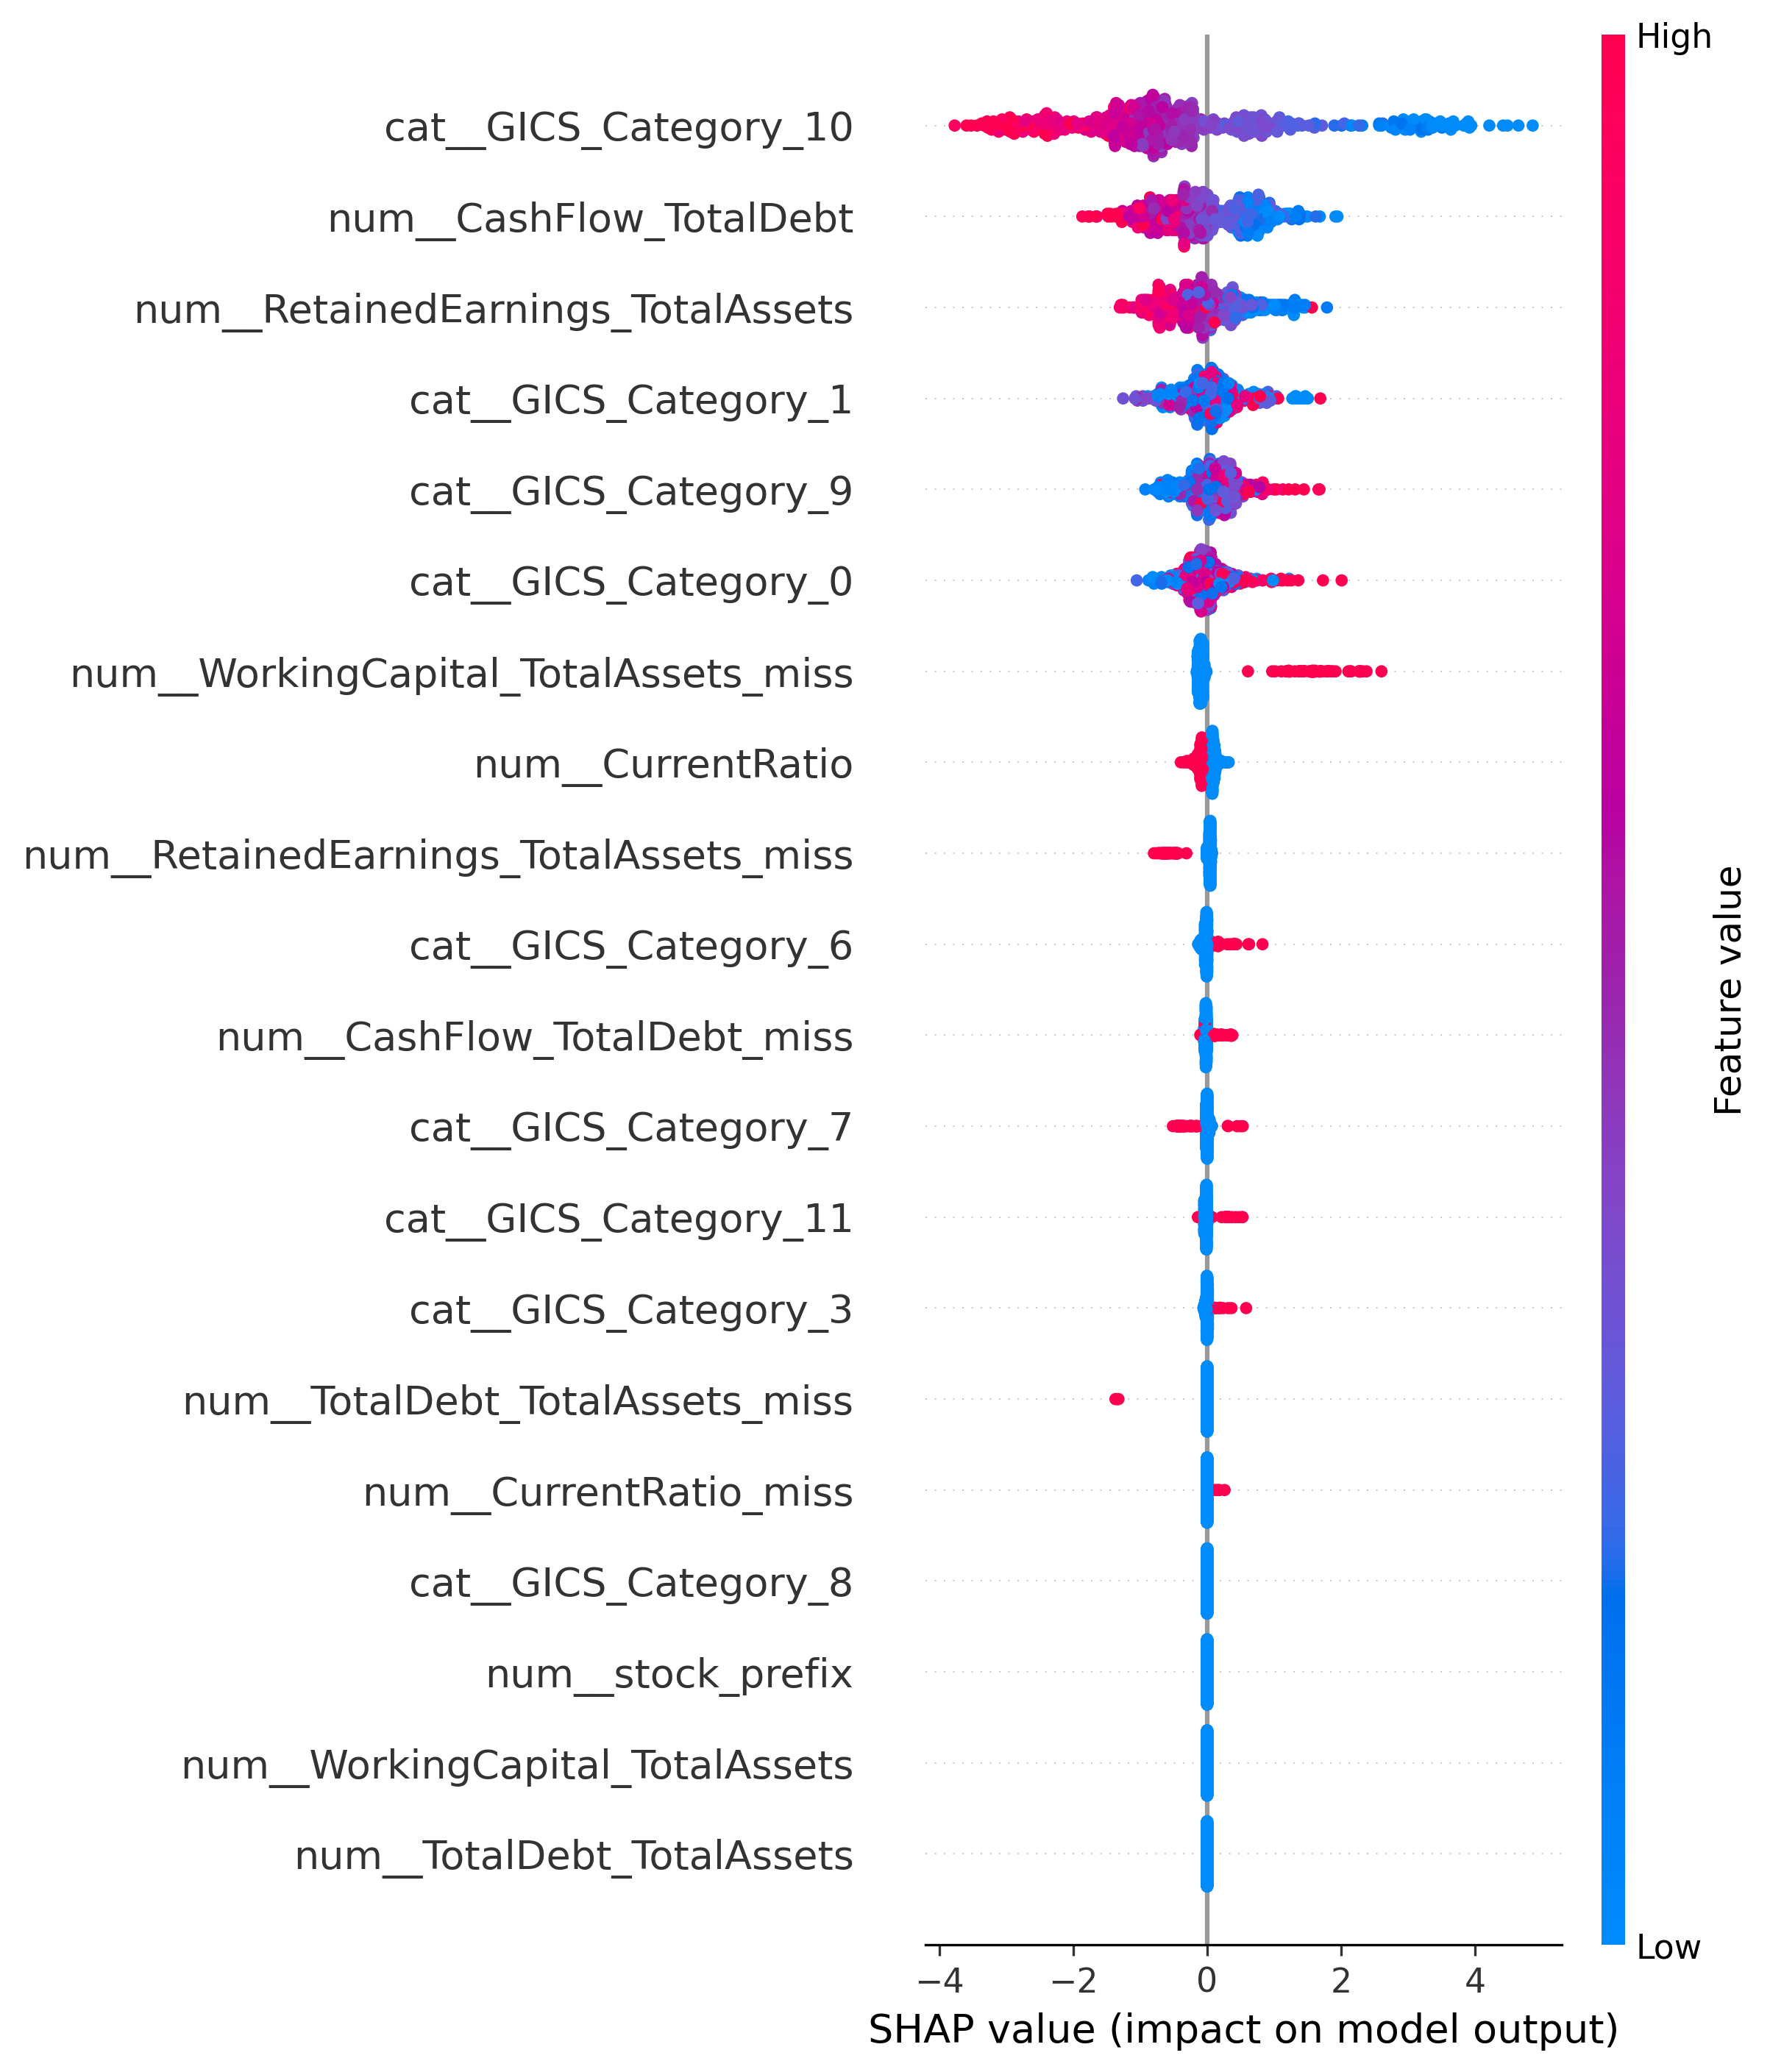

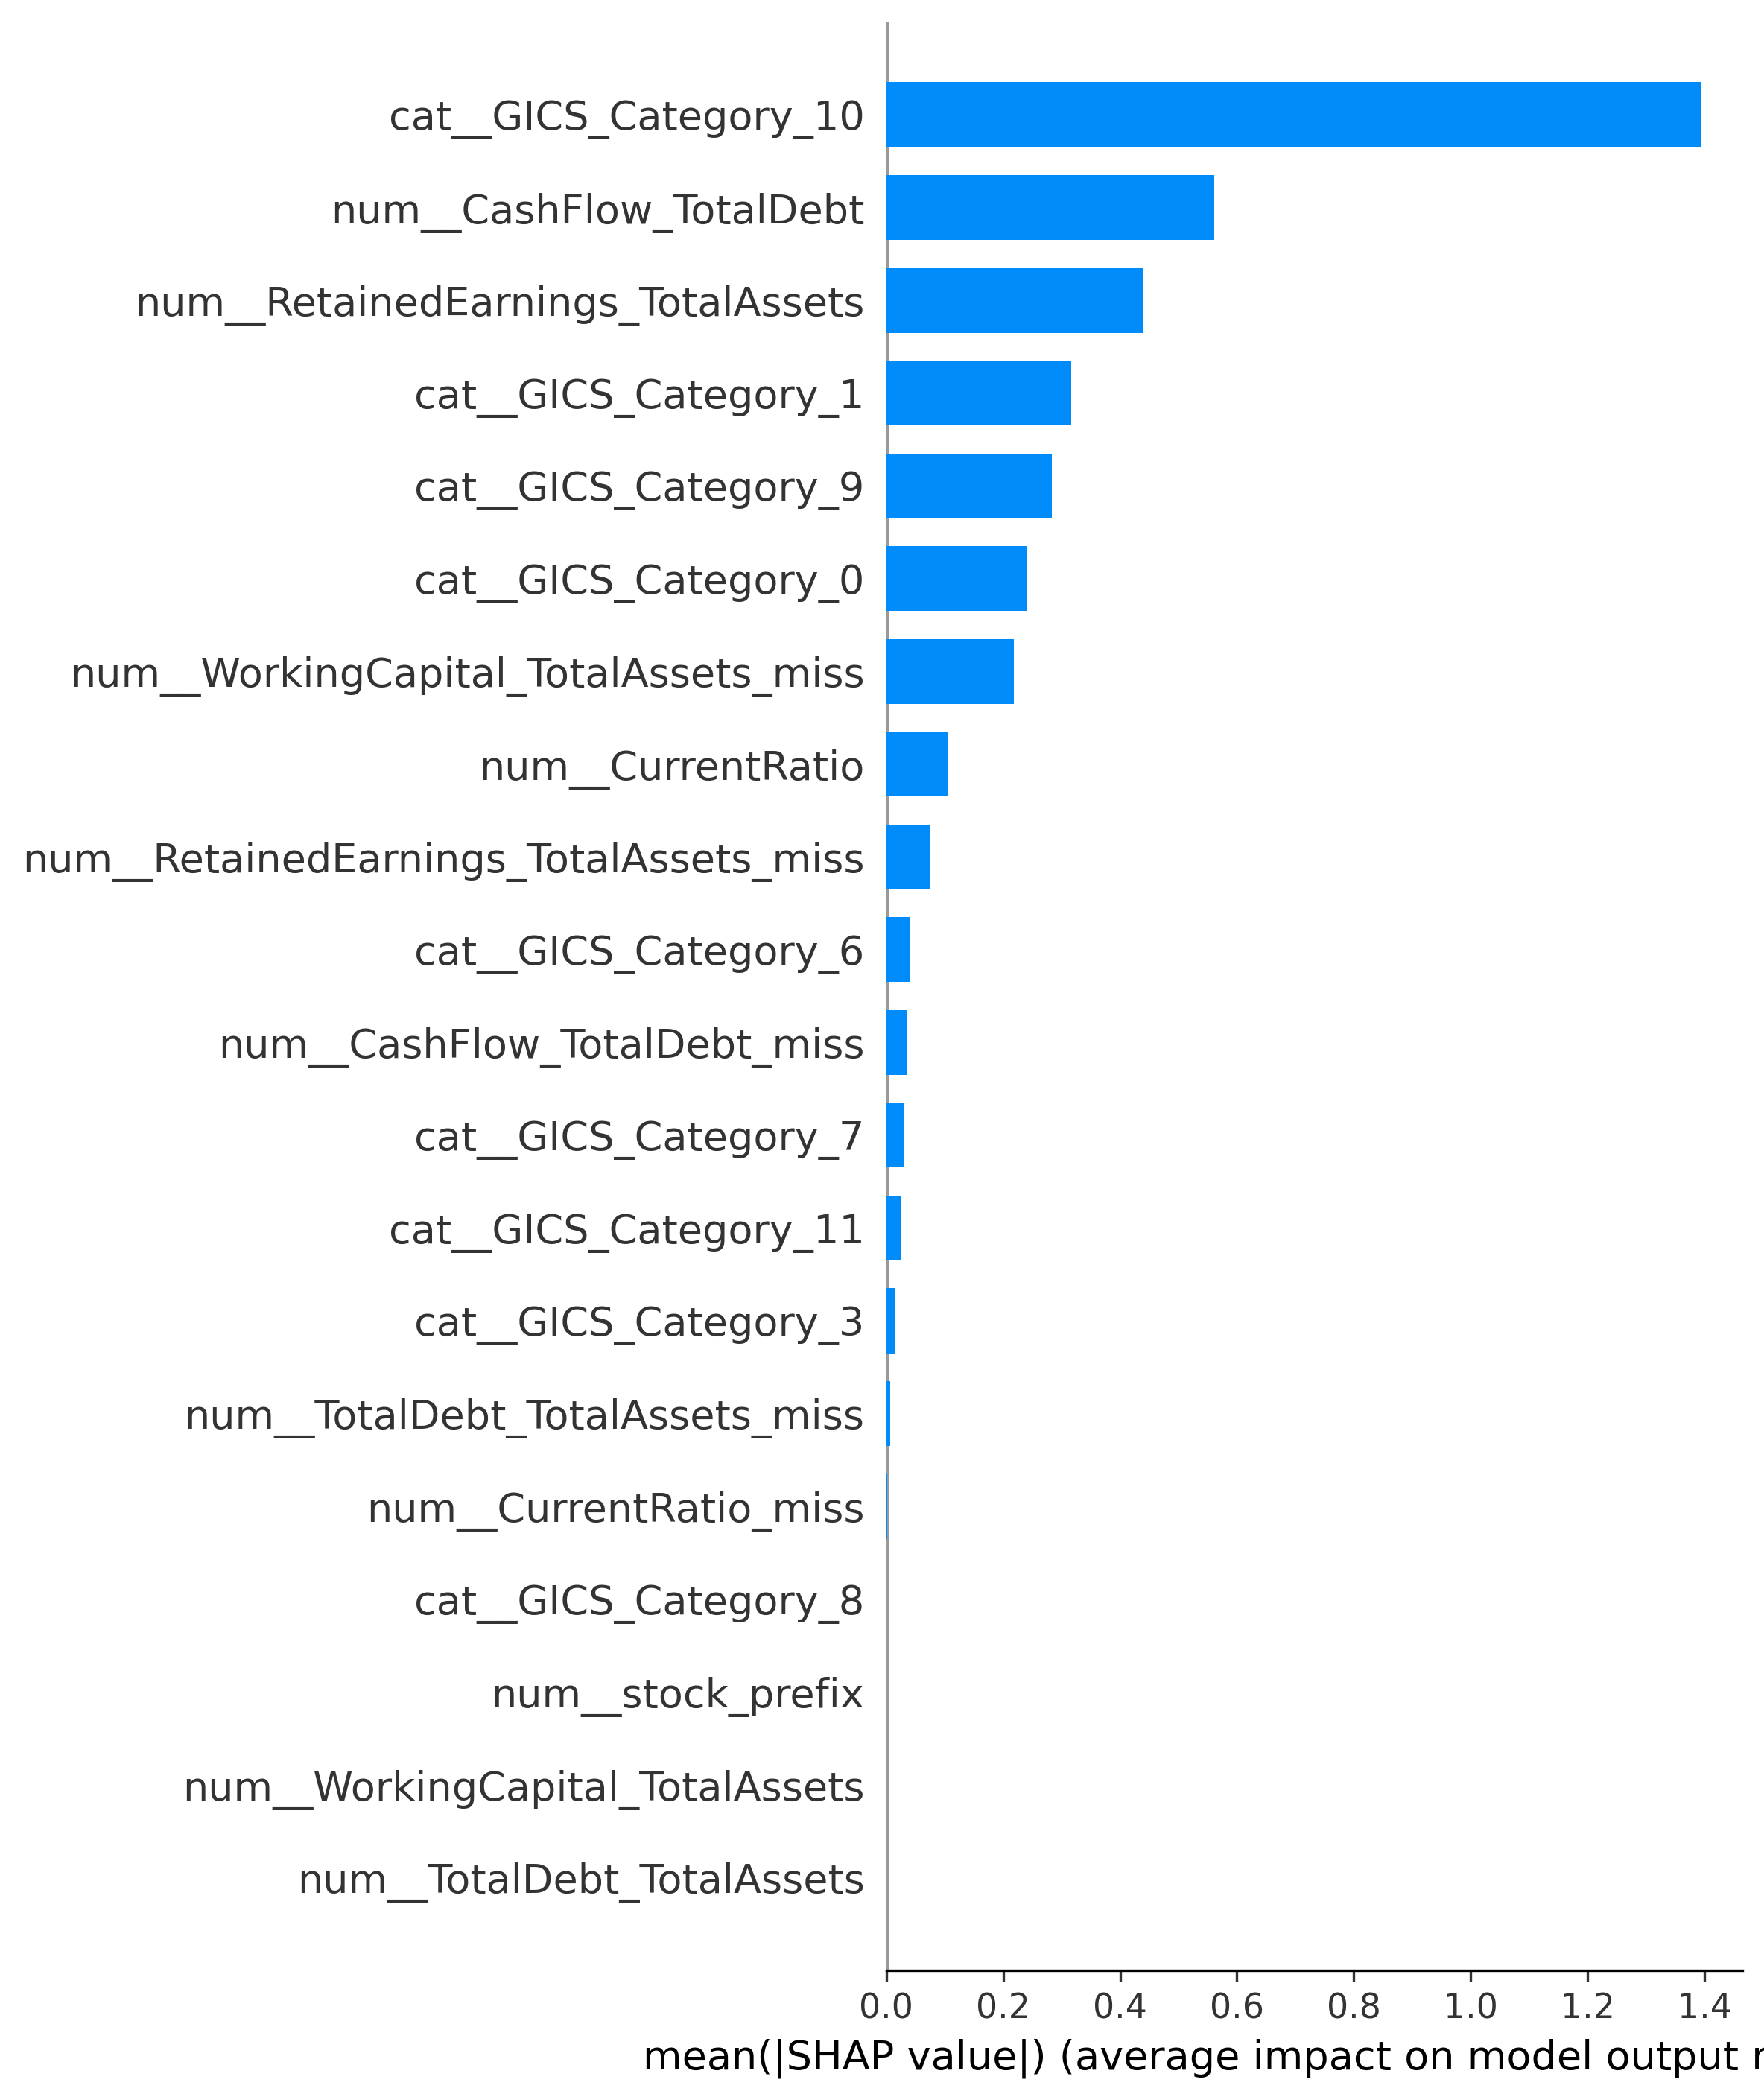

In [ ]:
from IPython.display import Image
display(Image(filename='outputs/plots/shap_summary_nn_model.png'))
display(Image(filename='outputs/plots/shap_bar_nn_model.png'))


In [ ]:
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/nn_model')
with open(f'{OUT_DIR}/metrics_summary.json','r',encoding='utf-8') as f:
    metrics_summary = json.load(f)
pd.DataFrame({k:v for k,v in metrics_summary.items() if isinstance(v,dict) and 'pr_auc' in v}).T


,pr_auc,roc_auc,f1,precision,recall,brier,logloss,ece,threshold,recall_at_p>=0.50,threshold_at_p>=0.50
raw,0.686438,0.822245,0.636145,0.559322,0.737430,0.150065,0.485935,0.076061,0.260046,0.815642,0.179154
platt,0.686438,0.822245,0.637681,0.561702,0.737430,0.149924,0.469593,0.063757,0.260046,0.815642,0.190289
isotonic,0.654971,0.822010,0.609603,0.486667,0.815642,0.152541,0.525073,0.083504,0.260046,0.737430,0.417722


In [ ]:
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/nn_model')
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f'{OUT_DIR}/predictions_test.csv')
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
confusion = pd.crosstab(preds['y_true'], preds['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
confusion = confusion.reindex(index=[0,1], columns=[0,1], fill_value=0)
confusion


y_pred,0,1
y_true,,
0,336,104
1,47,132


In [ ]:
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/nn_model')
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f'{OUT_DIR}/predictions_test.csv')
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
accuracy = (preds['y_pred_raw'] == preds['y_true']).mean()
print('accuracy:', accuracy)
